In [1]:
pip install yfinance

In [4]:
import yfinance as yf

stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS']

data = yf.download(stocks, start='2020-01-01', end='2024-01-01')

# Extract correct column
data = data['Close']   # instead of 'Adj Close'

data.head()

/tmp/ipykernel_619/2967613588.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  3 of 3 completed


Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2020-01-01,633.151062,675.324158,1866.114014
2020-01-02,631.303650,686.821228,1857.547974
2020-01-03,641.013428,687.648743,1894.567261
2020-01-06,634.869629,671.700623,1894.394775
2020-01-07,625.460693,682.034485,1899.043823


In [5]:
returns = data.pct_change()
returns.head()

Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2020-01-01,NaN,NaN,NaN
2020-01-02,-0.002918,0.017025,-0.004590
2020-01-03,0.015381,0.001205,0.019929
2020-01-06,-0.009585,-0.023192,-0.000091
2020-01-07,-0.014820,0.015385,0.002454


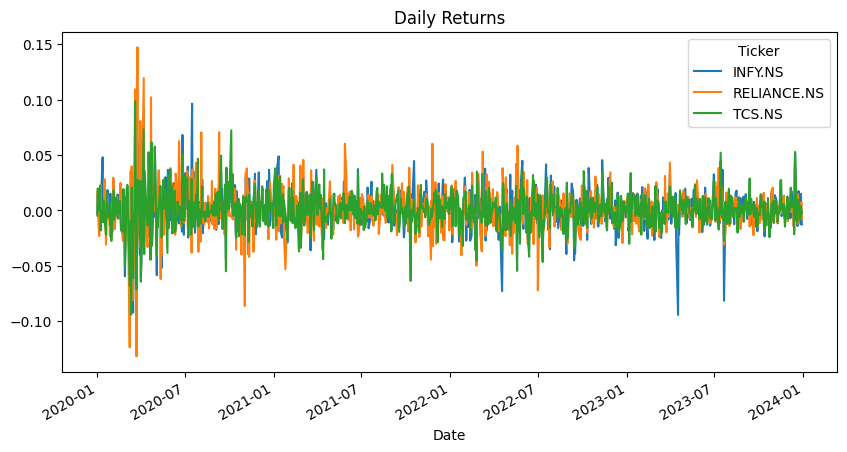

In [6]:
import matplotlib.pyplot as plt

returns.plot(figsize=(10,5))
plt.title("Daily Returns")
plt.show()

/tmp/ipykernel_619/3821256762.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(risk[i], mean_returns[i], mean_returns.index[i])


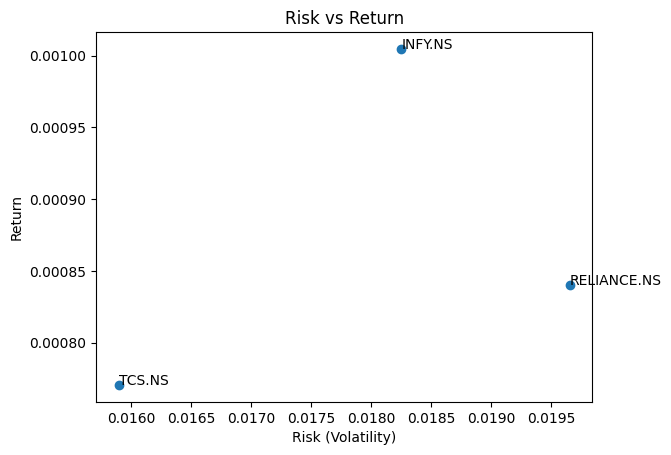

In [7]:
import numpy as np

mean_returns = returns.mean()
risk = returns.std()

plt.scatter(risk, mean_returns)

for i in range(len(mean_returns)):
    plt.text(risk[i], mean_returns[i], mean_returns.index[i])

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

In [8]:
weights = np.array([0.4, 0.3, 0.3])  # RELIANCE, TCS, INFY

In [9]:
portfolio_return = np.sum(mean_returns * weights)
print("Portfolio Return:", portfolio_return)

Portfolio Return: 0.000885120675413517


In [10]:
portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(returns.cov(), weights)))
print("Portfolio Risk:", portfolio_risk)

Portfolio Risk: 0.014704249498889968


In [11]:
weights = np.array([0.2, 0.5, 0.3])

In [16]:
risk_free_rate = 0.01  # 1% (approx)

In [17]:
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk
print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: -0.6198806219436477


In [18]:
import numpy as np

num_portfolios = 1000

results = []

for _ in range(num_portfolios):
    weights = np.random.random(3)
    weights /= np.sum(weights)

    port_return = np.sum(mean_returns * weights)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(returns.cov(), weights)))
    sharpe = (port_return - risk_free_rate) / port_risk

    results.append([port_return, port_risk, sharpe])

results = np.array(results)

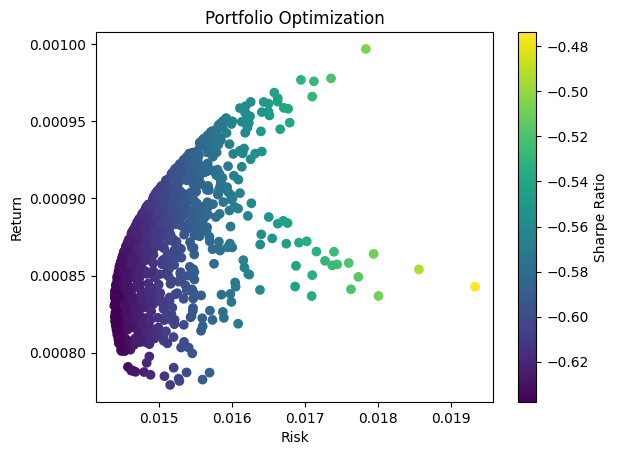

In [19]:
import matplotlib.pyplot as plt

plt.scatter(results[:,1], results[:,0], c=results[:,2])
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk')
plt.ylabel('Return')
plt.title('Portfolio Optimization')
plt.show()